<a href="https://colab.research.google.com/github/Jyothik178/Machine-Learning-Skill/blob/main/Week11_2420080039.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import numpy as np

class Perceptron:
    def __init__(self, lr=0.1, epochs=10):
        self.lr = lr
        self.epochs = epochs

    def activation(self, x):
        return np.where(x >= 0, 1, 0)

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        for _ in range(self.epochs):
            for xi, target in zip(X, y):
                linear = np.dot(xi, self.weights) + self.bias
                y_pred = self.activation(linear)
                update = self.lr * (target - y_pred)

                self.weights += update * xi
                self.bias += update

    def predict(self, X):
        linear = np.dot(X, self.weights) + self.bias
        return self.activation(linear)

In [2]:

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y_and = np.array([0,0,0,1])

p = Perceptron()
p.fit(X, y_and)
print("AND:", p.predict(X))

AND: [0 0 0 1]


In [3]:
y_or = np.array([0,1,1,1])

p.fit(X, y_or)
print("OR:", p.predict(X))

OR: [0 1 1 1]


In [4]:
y_xor = np.array([0,1,1,0])

p.fit(X, y_xor)
print("XOR:", p.predict(X))

XOR: [1 1 0 0]


In [5]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    return x * (1 - x)

class NeuralNetwork:
    def __init__(self):
        self.W1 = np.random.rand(2, 4)
        self.W2 = np.random.rand(4, 1)

    def forward(self, X):
        self.z1 = np.dot(X, self.W1)
        self.a1 = sigmoid(self.z1)

        self.z2 = np.dot(self.a1, self.W2)
        self.a2 = sigmoid(self.z2)
        return self.a2

    def train(self, X, y, epochs=10000, lr=0.1):
        for _ in range(epochs):
            output = self.forward(X)

            error = y - output
            d2 = error * sigmoid_deriv(output)

            error_hidden = d2.dot(self.W2.T)
            d1 = error_hidden * sigmoid_deriv(self.a1)

            self.W2 += self.a1.T.dot(d2) * lr
            self.W1 += X.T.dot(d1) * lr

In [6]:
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

nn = NeuralNetwork()
nn.train(X, y)

print("XOR Output:\n", nn.forward(X))

XOR Output:
 [[0.10014302]
 [0.92063723]
 [0.92773511]
 [0.05904135]]


In [7]:
def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

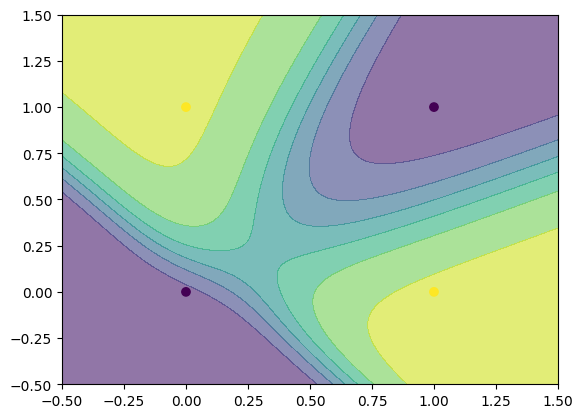

In [8]:

import matplotlib.pyplot as plt

def plot_boundary(model, X, y):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.forward(grid)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.6)
    plt.scatter(X[:,0], X[:,1], c=y.flatten())
    plt.show()

plot_boundary(nn, X, y)

In [9]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])

model = Sequential([
    Dense(4, input_dim=2, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X, y, epochs=200, verbose=0)

print("Predictions:", model.predict(X))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predictions: [[0.50105613]
 [0.50105613]
 [0.4972891 ]
 [0.50105613]]


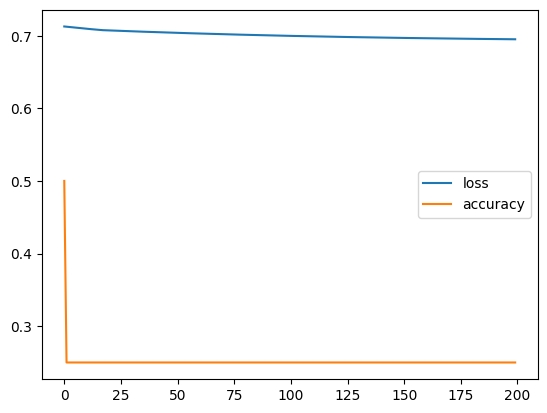

In [10]:

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['accuracy'], label='accuracy')
plt.legend()
plt.show()

In [13]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# ================== ACTIVATIONS ==================
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    return x * (1 - x)

def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(float)

# ================== DROPOUT ==================
def apply_dropout(X, rate):
    mask = (np.random.rand(*X.shape) > rate).astype(float)
    return X * mask / (1 - rate)

# ================== NEURAL NETWORK ==================
class NeuralNet:
    def __init__(self, inp, hid, out, lr=0.01, momentum=0.9, l2=0.001, optimizer="adam"):
        self.lr = lr
        self.momentum = momentum
        self.l2 = l2
        self.optimizer = optimizer

        self.W1 = np.random.randn(inp, hid)
        self.W2 = np.random.randn(hid, out)

        # momentum
        self.vW1 = np.zeros_like(self.W1)
        self.vW2 = np.zeros_like(self.W2)

        # adam
        self.mW1 = np.zeros_like(self.W1)
        self.vW1_adam = np.zeros_like(self.W1)
        self.mW2 = np.zeros_like(self.W2)
        self.vW2_adam = np.zeros_like(self.W2)
        self.t = 0

    def forward(self, X, training=True):
        self.z1 = X @ self.W1
        self.a1 = relu(self.z1)

        if training:
            self.a1 = apply_dropout(self.a1, 0.2)

        self.z2 = self.a1 @ self.W2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, X, y):
        m = len(X)

        error = self.a2 - y
        dW2 = self.a1.T @ error / m

        d_hidden = (error @ self.W2.T) * relu_deriv(self.a1)
        dW1 = X.T @ d_hidden / m

        # L2 regularization
        dW1 += self.l2 * self.W1
        dW2 += self.l2 * self.W2

        if self.optimizer == "momentum":
            self.vW1 = self.momentum * self.vW1 - self.lr * dW1
            self.vW2 = self.momentum * self.vW2 - self.lr * dW2
            self.W1 += self.vW1
            self.W2 += self.vW2

        elif self.optimizer == "adam":
            self.t += 1
            beta1, beta2, eps = 0.9, 0.999, 1e-8

            for W, dW, mW, vW in [
                (self.W1, dW1, self.mW1, self.vW1_adam),
                (self.W2, dW2, self.mW2, self.vW2_adam)
            ]:
                mW[:] = beta1 * mW + (1 - beta1) * dW
                vW[:] = beta2 * vW + (1 - beta2) * (dW ** 2)

                m_hat = mW / (1 - beta1 ** self.t)
                v_hat = vW / (1 - beta2 ** self.t)

                W -= self.lr * m_hat / (np.sqrt(v_hat) + eps)

        else:  # SGD
            self.W1 -= self.lr * dW1
            self.W2 -= self.lr * dW2

    def train(self, X, y, epochs=1000):
        for i in range(epochs):
            self.forward(X, training=True)
            self.backward(X, y)

# ================== IRIS DATA ==================
data = load_iris()
X = data.data
y = data.target.reshape(-1, 1)

enc = OneHotEncoder(sparse_output=False)
y = enc.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# ================== TRAIN ==================
model = NeuralNet(4, 8, 3, optimizer="adam")
model.train(X_train, y_train, epochs=2000)

# ================== TEST ==================
pred = model.forward(X_test, training=False)
pred_classes = np.argmax(pred, axis=1)
true_classes = np.argmax(y_test, axis=1)

accuracy = np.mean(pred_classes == true_classes)
print("Accuracy:", accuracy)

Accuracy: 0.9666666666666667
